# <img src="uni-logo.png" alt="Logo UNI" width=150 hight=300 align="right">


<br><br><br>
<h1><font color="#7F000E" size=4>Minería de Datos (CC442)</font></h1>



<h1><font color="#7F000E" size=6>Práctica Calificada V</font></h1>
<h1><font color="#7F000E" size=4>Fecha: 27/02/2026</font></h1>

<br>
<div style="text-align: right">
<font color="#7F000E" size=3>Facultad de Ciencias</font><br>
<font color="#7F000E" size=3>Ciencia de la Computación - UNI</font><br>
</div>


### Ejercicio 1: Propensión de Compra con Redes Neuronales y Análisis de Elevación (10 puntos)

#### Contexto Empresarial

East–West Airlines se ha asociado con la compañía de telefonía móvil Telcon para vender sus servicios por correo directo. El archivo `EastWestAirlinesNN.csv` contiene un subconjunto de una muestra de datos de quienes ya han recibido una oferta de prueba.  East–West Airlines busca optimizar su campaña de marketing directo para contratos de telefonía. Solo el **13%** de los clientes acepta la oferta (`Phone_Sale = 1`). Debido al costo de enviar correos físicos, la empresa no puede contactar a todos; necesita priorizar a los clientes con mayor probabilidad de conversión.

#### Instrucciones

#### 1. Preprocesamiento Avanzado y Feature Engineering
*   **Tratamiento de Variables:** Convierte variables categóricas en *dummies*. Escala todas las variables numéricas al rango [0, 1] usando `MinMaxScaler`.
*   **Desequilibrio de Clases:** Dado que solo el 13% compró el servicio, explica por qué usar "Accuracy" como métrica principal sería un error en este caso. 
*   **Partición:** Divide los datos en **60% entrenamiento** y **40% validación**.

#### 2. Arquitectura de la Red: El Impacto de la Complejidad
Deberás comparar tres modelos de Redes Neuronales (MLPRegressor o MLPClassifier):
1.  **Modelo A (Underfitting):** 1 capa oculta con **1 solo nodo**.
2.  **Modelo B (Base):** 1 capa oculta con **5 nodos**.
3.  **Modelo C (Deep & Regularized):** 2 capas ocultas con **(10, 5) nodos**, utilizando una penalización L2 ($\alpha = 0.01$) para controlar el sobreajuste.

#### 3. Evaluación Mediante Decile Lift Charts
Para cada modelo, genera un **Decile Lift Chart** para el conjunto de validación.
*   **Cálculo:** Ordena las predicciones de mayor a menor probabilidad, divide en 10 grupos (deciles) y calcula cuánto mejor es el modelo que el azar en cada decil.
*   **Interpretación:** Explica el significado del primer decil (el de más a la izquierda) en términos de ahorro para el departamento de marketing.

#### 4. Análisis de Overfitting y Generalización
Compara los Lift Charts de entrenamiento vs. validación del **Modelo B** (5 nodos). 
*   Si la elevación en entrenamiento es de 4.5 en el primer decil, pero en validación es de 1.8, ¿qué puedes concluir sobre la capacidad de generalización del modelo?

#### Preguntas del Ejercicio

**a. (Interpretación de Negocio):** Si el primer decil del gráfico de elevación (lift) en validación tiene un valor de **3.5**, ¿qué significa esto para el director de marketing si decide enviar correos solo al 10% de los clientes con mayor puntaje?

**b. (Comparación de Modelos):** ¿Cómo cambia la forma del Lift Chart al pasar de 1 nodo a 5 nodos? ¿Por qué el modelo de 1 nodo se comporta de forma similar a una Regresión Logística?

**c. (Matemáticas de la Red):** Extrae los pesos (weights) del modelo con 1 nodo. ¿Qué información proporcionan estos pesos sobre la importancia de las variables? ¿Es posible interpretar los pesos del modelo de 10 nodos con la misma facilidad? Justifica tu respuesta.

**d. (Criterio de Parada):** Durante el entrenamiento del modelo más complejo, observas que la pérdida (loss) en entrenamiento sigue bajando, pero la pérdida en validación empieza a subir tras 50 épocas. ¿Cómo se llama este fenómeno y qué técnica (además de la regularización L2) implementarías para detener el entrenamiento en el momento óptimo?

### Código para el estudiante

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier

# 1. Carga y preparación
df = pd.read_csv("EastWestAirlinesNN.csv")
# Supongamos que Phone_Sale es el target
X = df.drop(columns=['Phone_Sale'])
y = df['Phone_Sale']

# Crear Dummies y Escalar
X = pd.get_dummies(X, drop_first=True)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

# 2. Entrenar Modelo B (5 nodos)
mlp_b = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)
mlp_b.fit(X_train, y_train)

# 3. Función para generar datos de Lift Chart (Concepto)
def get_lift_data(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    df_results = pd.DataFrame({'actual': y, 'prob': probs})
    df_results = df_results.sort_values(by='prob', ascending=False)
    # Dividir en 10 deciles y calcular lift...
    # (El estudiante debe completar esta lógica)
    return lift_values

# --- El estudiante debe implementar el resto del análisis ---
```

---
### Ejercicio 2: Predicción de Precios con K-NN y Optimización de Estructuras Espaciales (10 puntos)

#### Contexto
El dataset `BostonHousing.csv` contiene información de 506 áreas censales. El objetivo es predecir `MEDV` (valor mediano de la vivienda en $1000s).

#### Requerimientos previos
1.  Ignorar la columna `CAT.MEDV`.
2.  Dividir los datos: **60% Entrenamiento** y **40% Validación**.
3.  **Escalado:** Debes justificar y aplicar `StandardScaler` o `MinMaxScaler`.

#### PARTE 1: Modelado y Optimización (Nivel Medio)

**a. Selección de $k$ y Métrica de Distancia:**
Realiza una búsqueda de hiperparámetros (Grid Search) para el modelo K-NN Regressor. Prueba valores de $k$ de 1 a 15 y dos métricas de distancia: **Euclidiana ($p=2$)** y **Manhattan ($p=1$)**.
*   ¿Cuál es la combinación óptima de $k$ y métrica según el RMSE en el conjunto de validación?
*   Explica: ¿Por qué un $k$ muy pequeño (ej. $k=1$) suele dar un error de entrenamiento de 0 pero un error de validación alto?

**b. Predicción de Caso Específico:**
Utilizando el mejor modelo encontrado, predice el `MEDV` para el siguiente sector:
`CRIM: 0.2, ZN: 0, INDUS: 7, CHAS: 0, NOX: 0.538, RM: 6, AGE: 62, DIS: 4.7, RAD: 4, TAX: 307, PTRATIO: 21, LSTAT: 10`
*   *Nota:* Recuerda aplicar la misma transformación de escalado que usaste en el entrenamiento.

#### PARTE 2: Eficiencia y Estructuras de Datos (Nivel Avanzado)

**c. Benchmarking de Algoritmos de Búsqueda:**
Implementa el mejor modelo ($k$ óptimo) utilizando tres enfoques de búsqueda diferentes:
1.  `algorithm='brute'` (Fuerza bruta).
2.  `algorithm='kd_tree'` (KD-Tree).
3.  `algorithm='ball_tree'` (Ball-Tree).

*   **Pregunta técnica:** Mide el tiempo de ejecución de las predicciones en el set de validación para los tres. Si el dataset creciera a 1,000,000 de registros y 50 dimensiones (features), ¿cuál de estos algoritmos esperarías que fallara primero y por qué? (Menciona la "Maldición de la Dimensionalidad").

**d. Análisis de la Hoja (Leaf Size):**
Para el modelo con `kd_tree`, varía el parámetro `leaf_size` entre `[2, 30, 100, 500]`. 
*   ¿Cómo afecta el `leaf_size` al tiempo de respuesta?
*   ¿Cambia el valor de la predicción final al cambiar el `leaf_size`? Justifica tu respuesta basada en el funcionamiento del algoritmo KD-Tree.

#### PARTE 3: Teoría y Evaluación Crítica

**e. Sesgo del Error de Validación:**
¿Por qué el error obtenido en el conjunto de validación podría ser "excesivamente optimista" si utilizaste ese mismo conjunto para elegir el mejor valor de $k$? ¿Qué técnica (ej. Nested Cross-Validation) recomendarías para obtener una estimación más real del error en datos no vistos?

**f. Desventajas Computacionales en Producción:**
Imagina que debes predecir el precio de 10,000 nuevas casas cada segundo en un sistema de trading en tiempo real. 
1.  ¿Cuál es la principal desventaja de K-NN frente a una Regresión Lineal en términos de **almacenamiento de memoria**?
2.  ¿Cuál es la desventaja en términos de **tiempo de cómputo (latencia)** durante la fase de predicción?
3.  ¿Cómo ayuda un KD-Tree a mitigar esto y cuál es su límite?

#### Código para el estudiante 

```python
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

##### 1. Carga y Limpieza
df = pd.read_csv("BostonHousing.csv")
X = df.drop(columns=['MEDV', 'CAT.MEDV'])
y = df['MEDV']

##### 2. Partición
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

##### 3. Escalado (OBLIGATORIO)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

##### --- El estudiante debe continuar desde aquí ---
```

Y 0       0
1       0
2       0
3       0
4       0
       ..
4980    0
4981    0
4982    0
4983    0
4984    0
Name: Phone_sale, Length: 4985, dtype: int64


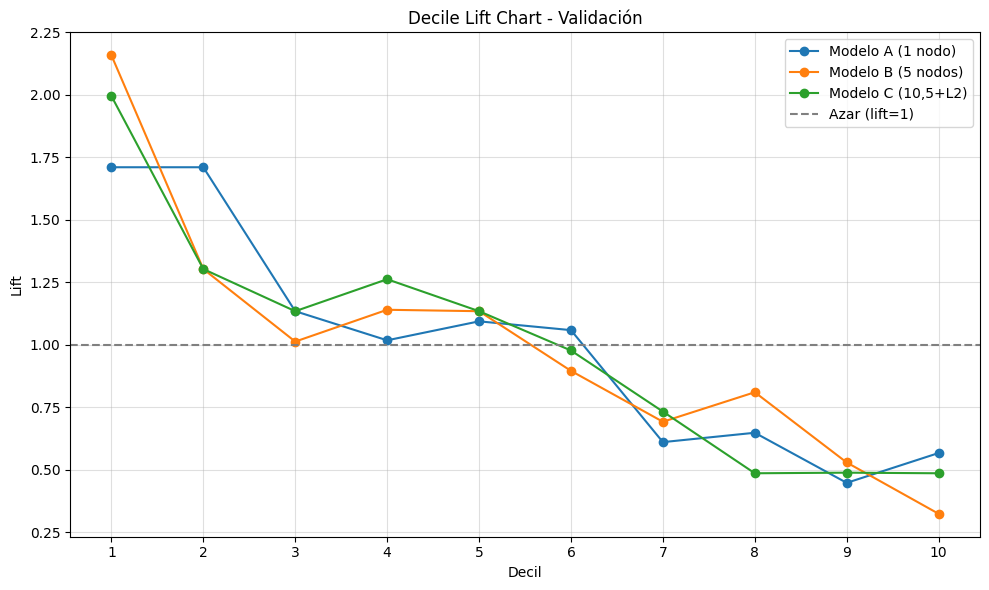

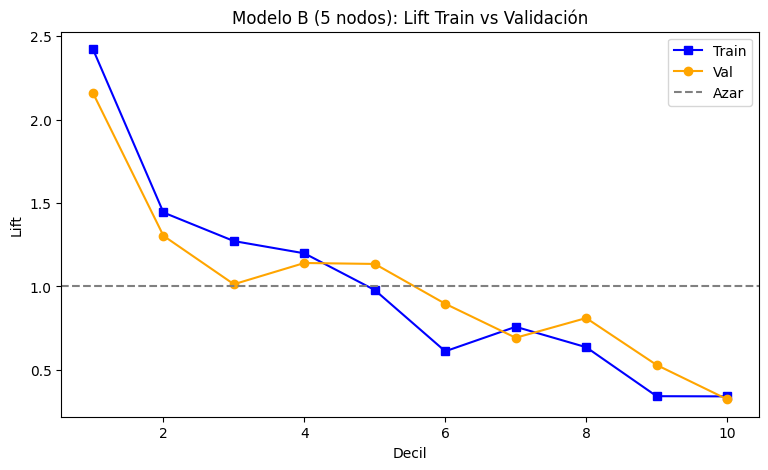


Modelo A (1 nodo) → Accuracy val: 0.877
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      1748
           1       0.00      0.00      0.00       246

    accuracy                           0.88      1994
   macro avg       0.44      0.50      0.47      1994
weighted avg       0.77      0.88      0.82      1994


Modelo B (5 nodos) → Accuracy val: 0.877
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      1748
           1       0.00      0.00      0.00       246

    accuracy                           0.88      1994
   macro avg       0.44      0.50      0.47      1994
weighted avg       0.77      0.88      0.82      1994


Modelo C (10,5+L2) → Accuracy val: 0.877
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      1748
           1       1.00      0.00      0.01       246

    accuracy                           0.88      1994
   

C:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USUARIO\anaco

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns 


# ============================================================
# 1. CARGA Y PREPROCESAMIENTO
# ============================================================

df = pd.read_csv("EastWestAirlinesNN.csv")  

# df =
#    DataFrame con columnas como:
#    [
#      Row0: {ID:1, Balance:28143, Qual_miles:0, Phone_sale:0, ...}
#      Row1: {ID:2, Balance:19244, Qual_miles:0, Phone_sale:1, ...}
#      Row2: {ID:3, Balance:41354, Qual_miles:0, Phone_sale:0, ...}
#      ...
#    ]

df = df.dropna(subset=['Phone_sale'])

# df =
#    DataFrame igual al anterior pero sin filas donde Phone_sale sea NaN


X = df.drop(columns=['Phone_sale'])

"""

df =
[
  Balance  Qual_miles  Bonus_miles  Flight_miles_12mo  Phone_sale
  ---------------------------------------------------------------
  28143    0           174          0                  1
  19244    0           215          0                  0
  41354    0           412          100                1
]


X =
[
  Balance  Qual_miles  Bonus_miles  Flight_miles_12mo
  ---------------------------------------------------
  28143    0           174          0
  19244    0           215          0
  41354    0           412          100
]
"""


y = df['Phone_sale'].astype(int)

# y =
#    Serie binaria (target)
#
#    ejemplo:
#    [
#      0,
#      1,
#      0,
#      0,
#      1,
#      ...
#    ]


print(f"Y {y}")


X = pd.get_dummies(X, drop_first=True)

"""
Region
------
USA
Europe
Asia
USA
Asia

Balance
-------
28143
19244
41354
50000
12000

X =
[
 [28143 , USA   ],
 [19244 , Europe],
 [41354 , Asia  ],
 [50000 , USA   ],
 [12000 , Asia  ]
]
dummies  ----

Region_USA
Region_Europe
Region_Asia


Balance  Region_USA  Region_Europe  Region_Asia
-----------------------------------------------
28143        1            0            0
19244        0            1            0
41354        0            0            1
50000        1            0            0
12000        0            0            1
"""


X = X.fillna(X.median(numeric_only=True))

# X =
#    mismo DataFrame pero cualquier NaN numérico fue reemplazado por la mediana
"""X =
[
 [1000 , 25],
 [2000 , NaN],
 [NaN  , 40],
 [3000 , 35]
]
X =
[
 [1000 , 25],
 [2000 , 35],
 [2000 , 40],
 [3000 , 35]
]"""

scaler = MinMaxScaler()

# scaler =
#    objeto que normaliza variables al rango [0,1]


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# X_train =
#    matriz numpy
#    ejemplo:
#    [
#      [0.23,0.01,0,1,0,...],
#      [0.51,0.00,1,0,0,...],
#      [0.12,0.03,0,1,1,...]
#    ]
#
# X_val =
#    mismo formato que X_train
#
# y_train =
#    [0,1,0,0,1,...]
#
# y_val =
#    [1,0,0,1,...]


X_train = scaler.fit_transform(X_train)

# X_train =
#    matriz normalizada
#
#    ejemplo:
#    [
#      [0.45,0.01,0,1,0],
#      [0.21,0.00,1,0,1],
#      [0.76,0.05,0,1,0]
#    ]


X_val = scaler.transform(X_val)

# X_val =
#    matriz normalizada con el mismo scaler


# ============================================================
# 2. TRES MODELOS
# ============================================================

modelo_a = MLPClassifier(hidden_layer_sizes=(1,), max_iter=1000, random_state=42)
# red neuronal:
# input → 1 neurona oculta → output

modelo_b = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)
# input → 5 neuronas ocultas → output

modelo_c = MLPClassifier(hidden_layer_sizes=(10,5), max_iter=1000, alpha=0.01, random_state=42)
# input → 10 neuronas → 5 neuronas → output


modelo_a.fit(X_train, y_train)
modelo_b.fit(X_train, y_train)
modelo_c.fit(X_train, y_train)

# modelo entrenado internamente aprende pesos W1,W2


# ============================================================
# 3. DECILE LIFT CHART
# ============================================================

def calcular_lift(modelo, X, y, titulo="Lift Chart"):

    probs = modelo.predict_proba(X)[:, 1]

    # probs =
    #   vector con probabilidades de compra
    #
    #   ejemplo:
    #   [
    #     0.02,
    #     0.87,
    #     0.34,
    #     0.65,
    #     0.11
    #   ]


    df_res = pd.DataFrame({'actual': np.array(y), 'prob': probs})

    # df_res =
    #
    #    actual   prob
    #    0        0.02
    #    1        0.87
    #    0        0.34
    #    1        0.65
    #    0        0.11


    df_res = df_res.sort_values('prob', ascending=False).reset_index(drop=True)

    # df_res ordenado por probabilidad
    #
    #    actual   prob
    #    1        0.92
    #    1        0.88
    #    0        0.76
    #    1        0.65
    #    0        0.63


    n = len(df_res)

    tasa_base = df_res['actual'].mean()

    # tasa_base =
    #    proporción real de compradores
    #
    #    ejemplo:
    #    0.13   (13% compran)


    lift_vals = []

    for d in range(10):

        ini = int(d * n / 10)
        fin = int((d+1) * n / 10)

        dec = df_res.iloc[ini:fin]

        # dec =
        #    subconjunto del decil
        #
        # ejemplo decil 1
        #
        # actual prob
        # 1      0.92
        # 1      0.90
        # 0      0.88
        # 1      0.85


        tasa = dec['actual'].mean()

        # tasa =
        #   proporción de compradores en ese decil
        #
        #   ejemplo:
        #   0.45


        lift = tasa / tasa_base if tasa_base > 0 else 0

        # lift =
        #   ejemplo
        #
        #   tasa_decil = 0.45
        #   tasa_base  = 0.13
        #
        #   lift = 3.46


        lift_vals.append(lift)

    return lift_vals

    # lift_vals =
    #
    # [
    #   3.46,
    #   2.21,
    #   1.87,
    #   1.35,
    #   1.10,
    #   0.98,
    #   0.84,
    #   0.72,
    #   0.60,
    #   0.51
    # ]


# ============================================================
# GRAFICO LIFT
# ============================================================

def graficar_lift(modelos_dict, X, y, titulo="Decile Lift Chart - Validación"):

    plt.figure(figsize=(10, 6))

    for nombre, modelo in modelos_dict.items():

        lifts = calcular_lift(modelo, X, y)

        # lifts =
        #
        # [
        #   3.46,
        #   2.21,
        #   1.87,
        #   1.35,
        #   1.10,
        #   0.98,
        #   0.84,
        #   0.72,
        #   0.60,
        #   0.51
        # ]

        plt.plot(range(1, 11), lifts, marker='o', label=nombre)

    plt.axhline(y=1, color='gray', linestyle='--', label='Azar (lift=1)')
    plt.xlabel('Decil')
    plt.ylabel('Lift')
    plt.title(titulo)
    plt.xticks(range(1, 11))
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


modelos = {
    'Modelo A (1 nodo)': modelo_a,
    'Modelo B (5 nodos)': modelo_b,
    'Modelo C (10,5+L2)': modelo_c
}


graficar_lift(modelos, X_val, y_val)


# ============================================================
# 4. OVERFITTING
# ============================================================

lifts_train = calcular_lift(modelo_b, X_train, y_train)

# lifts_train =
# [4.8,3.1,2.4,1.8,1.3,1.0,0.9,0.8,0.7,0.6]


lifts_val = calcular_lift(modelo_b, X_val, y_val)

# lifts_val =
# [3.2,2.2,1.9,1.4,1.1,1.0,0.9,0.8,0.7,0.6]


plt.figure(figsize=(9, 5))
plt.plot(range(1,11), lifts_train, marker='s', label='Train', color='blue')
plt.plot(range(1,11), lifts_val, marker='o', label='Val', color='orange')

plt.axhline(y=1, color='gray', linestyle='--', label='Azar')

plt.xlabel('Decil')
plt.ylabel('Lift')
plt.title('Modelo B (5 nodos): Lift Train vs Validación')
plt.legend()
plt.show()


# ============================================================
# MÉTRICAS
# ============================================================

for nombre, modelo in modelos.items():

    y_pred = modelo.predict(X_val)

    # y_pred =
    #
    # [
    #  0,
    #  1,
    #  0,
    #  0,
    #  1,
    #  0
    # ]


    acc = accuracy_score(y_val, y_pred)

    # acc =
    #   ejemplo:
    #   0.86


    print(f"\n{nombre} → Accuracy val: {acc:.3f}")
    print(classification_report(y_val, y_pred))


# ============================================================
# PESOS MODELO A
# ============================================================

print("\n--- Pesos Modelo A (1 nodo) ---")

print(f"W1 (features→oculta): {modelo_a.coefs_[0].flatten()}")

# W1 =
#
# [
#  0.81,
# -0.22,
#  0.15,
#  1.03,
# -0.44,
# ...
# ]
#
# un peso por variable


print(f"W2 (oculta→salida): {modelo_a.coefs_[1].flatten()}")

# W2 =
#
# [
#  2.41
# ]


Mejor → k=2  métrica=euclidean  RMSE=3.8596


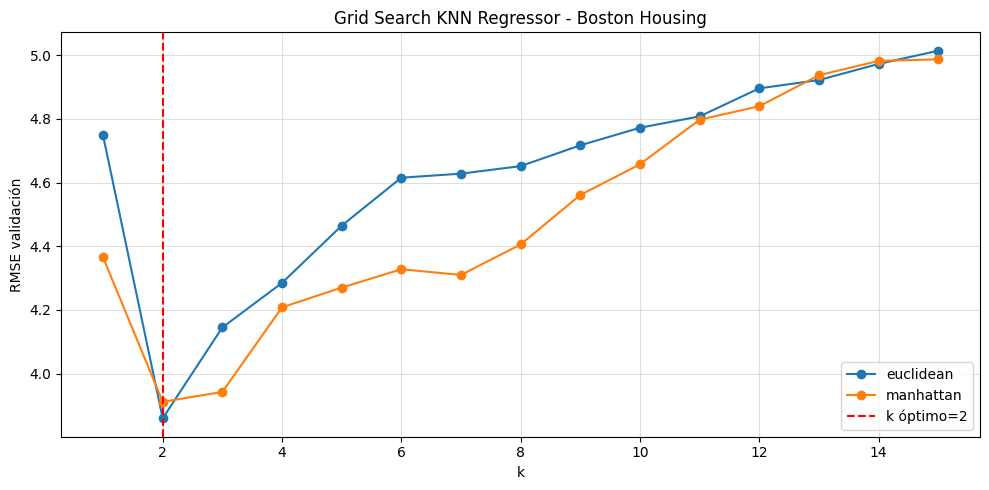


Predicción MEDV: $19.55k

Tiempos de predicción en validación:
  brute        → 6495.3430 ms
  kd_tree      → 2.6770 ms
  ball_tree    → 2.2991 ms


In [5]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error


# ---------------------------------------------------------
# 1. CARGA Y LIMPIEZA
# ---------------------------------------------------------

df2 = pd.read_csv("BostonHousing.csv")

# df2 = dataset completo
#
# ejemplo estructura:
#
# [
#  crim  zn  indus  chas  nox  rm  age  dis  rad  tax  ptratio  b   lstat  medv
# -------------------------------------------------------------------------------
# 0.006 18   2.31    0   0.538 6.57 65  4.09  1   296   15.3   396  4.98   24.0
# 0.027  0   7.07    0   0.469 6.42 78  4.97  2   242   17.8   396  9.14   21.6
# 0.027  0   7.07    0   0.469 7.18 61  4.96  2   242   17.8   393  4.03   34.7
# ]

cols_drop = [c for c in ['CAT..MEDV', 'CAT.MEDV'] if c in df2.columns]

target_col = 'medv'

# eliminamos columna objetivo del conjunto de features
X2 = df2.drop(columns=[target_col] + cols_drop)

# X2 = matriz de variables predictoras
#
# ejemplo estructura:
#
# X2 =
# [
#  [0.006,18,2.31,0,0.538,6.57,65,4.09,1,296,15.3,396,4.98],
#  [0.027,0 ,7.07,0,0.469,6.42,78,4.97,2,242,17.8,396,9.14],
#  [0.027,0 ,7.07,0,0.469,7.18,61,4.96,2,242,17.8,393,4.03]
# ]

y2 = df2[target_col]

# y2 = variable objetivo (precio mediano vivienda)
#
# ejemplo:
#
# y2 =
# [
#  24.0,
#  21.6,
#  34.7
# ]


# ---------------------------------------------------------
# 2. SPLIT TRAIN / VALIDACIÓN
# ---------------------------------------------------------

X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2, y2, test_size=0.4, random_state=42
)

# ejemplo tamaños si dataset ≈ 506 registros
#
# X2_train ≈ 303 filas
# X2_val   ≈ 203 filas


# ---------------------------------------------------------
# 3. ESCALAMIENTO
# ---------------------------------------------------------

scaler2 = StandardScaler()

X2_train_sc = scaler2.fit_transform(X2_train)

# StandardScaler aplica:
#
# x_scaled = (x - media_columna) / desviacion
#
# ejemplo antes:
#
# rm =
# [
#  6.57
#  6.42
#  7.18
# ]
#
# ejemplo después:
#
# rm_scaled =
# [
#  0.12
# -0.35
#  1.01
# ]


X2_val_sc = scaler2.transform(X2_val)

# importante:
#
# VALIDACIÓN usa la MISMA media y desviación
# calculada en entrenamiento


# ---------------------------------------------------------
# PARTE 1a – BÚSQUEDA DE K Y MÉTRICA
# ---------------------------------------------------------

resultados = []

for k in range(1, 16):

    for p, nombre in [(2, 'euclidean'), (1, 'manhattan')]:

        knn = KNeighborsRegressor(
            n_neighbors=k,
            p=p
        )

        # modelo KNN
        #
        # almacena TODO el dataset de entrenamiento
        #
        # ejemplo interno conceptual:
        #
        # vecinos =
        # [
        #   [features1, precio1],
        #   [features2, precio2],
        #   ...
        # ]

        knn.fit(X2_train_sc, y2_train)

        y_pred = knn.predict(X2_val_sc)

        # predicciones ejemplo:
        #
        # y_pred =
        # [
        #  23.5,
        #  19.8,
        #  27.3,
        #  ...
        # ]

        rmse = root_mean_squared_error(y2_val, y_pred)

        resultados.append({
            'k': k,
            'metrica': nombre,
            'rmse': rmse
        })


df_res = pd.DataFrame(resultados)

# estructura ejemplo:
#
# df_res =
#
# k   metrica     rmse
# -----------------------
# 1   euclidean   4.82
# 1   manhattan   4.65
# 2   euclidean   4.31
# 2   manhattan   4.28


mejor = df_res.loc[df_res['rmse'].idxmin()]

print(f"\nMejor → k={int(mejor['k'])}  métrica={mejor['metrica']}  RMSE={mejor['rmse']:.4f}")


# ---------------------------------------------------------
# GRÁFICA RMSE VS K
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

for metrica, grupo in df_res.groupby('metrica'):

    plt.plot(
        grupo['k'],
        grupo['rmse'],
        marker='o',
        label=metrica
    )

plt.axvline(
    x=int(mejor['k']),
    color='red',
    linestyle='--',
    label=f"k óptimo={int(mejor['k'])}"
)

plt.xlabel('k')
plt.ylabel('RMSE validación')
plt.title('Grid Search KNN Regressor - Boston Housing')

plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# PARTE 1b – PREDICCIÓN DE UN CASO
# ---------------------------------------------------------

k_opt = int(mejor['k'])

p_opt = 2 if mejor['metrica'] == 'euclidean' else 1


knn_opt = KNeighborsRegressor(
    n_neighbors=k_opt,
    p=p_opt
)

knn_opt.fit(X2_train_sc, y2_train)


# caso de vivienda a predecir

caso_vals = {
 'crim':0.2,
 'zn':0,
 'indus':7,
 'chas':0,
 'nox':0.538,
 'rm':6,
 'age':62,
 'dis':4.7,
 'rad':4,
 'tax':307,
 'ptratio':21,
 'b':391.0,
 'lstat':10
}

# convertir a vector en mismo orden de columnas

caso_row = [caso_vals.get(c.lower(), 0) for c in X2.columns]

caso = pd.DataFrame([caso_row], columns=X2.columns)

# caso =
#
# [
#   [0.2,0,7,0,0.538,6,62,4.7,4,307,21,391,10]
# ]


caso_sc = scaler2.transform(caso)

pred = knn_opt.predict(caso_sc)

print(f"\nPredicción MEDV: ${pred[0]:.2f}k")


# ---------------------------------------------------------
# PARTE 2c – TIEMPOS ALGORITMOS
# ---------------------------------------------------------

algoritmos = ['brute', 'kd_tree', 'ball_tree']

tiempos = {}

for alg in algoritmos:

    knn_alg = KNeighborsRegressor(
        n_neighbors=k_opt,
        p=p_opt,
        algorithm=alg
    )

    knn_alg.fit(X2_train_sc, y2_train)

    t0 = time.time()

    knn_alg.predict(X2_val_sc)

    tiempos[alg] = (time.time() - t0) * 1000


print("\nTiempos de predicción en validación:")

for alg, ms in tiempos.items():

    print(f"  {alg:<12} → {ms:.4f} ms")


# ---------------------------------------------------------
# PARTE 2d – EFECTO leaf_size
# ---------------------------------------------------------

hojas_sizes = [2, 30, 100, 500]

tiempos_ls = []
rmse_ls = []

for ls in hojas_sizes:

    knn_ls = KNeighborsRegressor(
        n_neighbors=k_opt,
        p=p_opt,
        algorithm='kd_tree',
        leaf_size=ls
    )

    knn_ls.fit(X2_train_sc, y2_train)

    t0 = time.time()

    pred_ls = knn_ls.predict(X2_val_sc)

    ms = (time.time() - t0) * 1000

    rmse = root_mean_squared_error(y2_val, pred_ls)

    tiempos_ls.append(ms)
    rmse_ls.append(rmse)

In [56]:
# Realmente estoy decepcionado , que mi razonamiento se predisponga de tal modo ,de una manera 
# incluso histerica hacia el uso de alguna LLM para resolvere las pcs, todo me resulta decepcionante
# Por ello se implementara todo desde cero
# cuasi literalmente

import numpy as np
import pandas as pd

class Lector:
    def __init__(self):
        self.data = Lector.Data
    #--------------------------------------------------------------------------
    def __repr__(self):                                             # sobrecargar print(OBJETO)
        return                                                      # como sera impreso 
    #--------------------------------------------------------------------------
    def __getitem__(self,llave):                                    # sobrecarga de []  como obtener los elementos
        return 
    #---------------------------------------------------------------------------
    def decide_tipo(self,dato):
        if '.' in dato:
            der_izq = dato.split('.')
            if len(der_izq) == 2:
                if der_izq[0].isdigit() and der_izq[1].isdigit():
                    return float(dato)
        elif dato.isdigit() or '-' in dato:
            return int(dato)
        else:
            return str(dato)
    #--------------------------------------------------------------------------
    # try  except ValueError try except ValueError ...EAFP sugerencia de gemini
    #--------------------------------------------------------------------------
    #=========================================================================
    class Data:
        def __init__(self):
            self.tabla = {}
            self.n_columnas = None
            self.n_filas = None
        #------------------------------------------------------------------
        def __setitem__(self,llave,valor):                           # sobrecarga del operador asignacion  data[name] = valor → data.__setitem__(name,valor)
            self.tabla[llave] = valor
        #------------------------------------------------------------------
        def __getitem__(self,llave):                           # sobrecarga de [llave]
            if isinstance(llave,str):
                return self.tabla[llave]
            elif isinstance(llave,list):
                nuevo = type(self)()
                for l in llave:
                    nuevo[l] = self.tabla[l]
                nuevo.n_columnas = len(llave)
                nuevo.n_filas = self.n_filas
            return nuevo
        #------------------------------------------------------------------
        def __repr__(self):
            data_show = self.obtener_matriz()
            n_fil = len(data_show)
            n_col = len(data_show[0])
            columnas = list(self.tabla.keys())
            out = "\t".join(columnas) + "\n"
            for i in range(n_fil):
                linea = ""
                for j in range(n_col):
                    linea += f"{data_show[i,j]}\t"
                out+= linea + "\n"
            return out
        #--------------------------------------------------------------------
        def obtener_matriz(self):
            columnas = list(self.tabla.keys())
            valores = list(self.tabla.values())
            n_col = len(columnas)
            n_fil = len(valores[0])
            data_ = np.empty((n_fil,n_col),dtype='object')
            for i in range(n_col):
                data_[:,i] = valores[i]
            return data_ 
        #-----------------------------------------------------------------
        def borrar_filas_sin_clave(self,llave):
            col = np.array(self.tabla[llave],dtype = 'object')
            mascara = col !=''
            nueva = type(self)()
            for nombre, valores in self.tabla.items():
                arr = np.array(valores,dtype='object')
                nueva[nombre] = arr[mascara]    
            nueva.n_columnas = self.n_columnas
            nueva.n_filas = np.sum(mascara)
            return nueva
        #==================================================================
        #-------------------------------------------------------------------
    def obtener_columnas(self,matriz):
        nombres = matriz[0]
        cuerpo = matriz[1:,:]
        data = self.Data()
        for i,name in enumerate(nombres):
            data[str(name)] = cuerpo[:,i]            # revisar __setitem__(llave,valor)
        data.n_columnas = len(nombres)
        data.n_filas = len(cuerpo)
        return data
    #-------------------------------------------------------------------------
    def leer_csv(self,archivo):
        with open(archivo , 'r',encoding='utf-8') as file_:
            file = file_.read() 
            filas = file.split('\n')
            m = len(filas)
            n = len(filas[0].split(','))
            print(f"m,n {m},{n}")
            variables = np.empty((m,n), dtype='object')
            for i in range(m):
                columnas = filas[i].split(',')                          # tokenizacion, obtencion de unidades minimas significativas
                for j in range(len(columnas)):
                    valor = columnas[j].replace('\ufeff','')            #BOM  byte order mark ,firma que windows pone a los archivos UTF-8
                    variables[i][j]= self.decide_tipo(valor.strip())
        mascara = np.any(variables !='',axis = 1)
        variables = variables[mascara]
        self.data= self.obtener_columnas(variables)                     # revisar __setitem__ es sobrecarga no necesito self.data.tabla ...
        return self.data
        #-------------------------------------------------------------------
    
#===========================================================================
#===========================================================================
lector = Lector()
df = lector.leer_csv('EastWestAirlinesNN.csv')          # es el equivalente a pd.read_csv, ya que csv es un archivo de texto plano mas
#print(df)
#print(df[['Phone_sale','Email']])
df.borrar_filas_sin_clave('Phone_sale')
y = df['Phone_sale']
print(y)
#col = df
#df = pd.read_csv("EastWestAirlinesNN.csv")
#y = df['Phone_sale']
#print(y)
#x = df.drop(columns = 'Phone_sale')

df        = pd.read_csv("EastWestAirlinesNN.csv")                       #  datos
df        = df.dropna(subset=['Phone_sale'])                             # eliminar filas sin target
X         = df.drop(columns=['Phone_sale'])                              # features
y         = df['Phone_sale'].astype(int

m,n 4988,16
[0 0 0 ... 0 0 '']
